# MATH GR5360 Final Project — Two-Market Diagnostics Story

This notebook tells the professor-facing diagnostics story in the intended order: `TY` first, then `BTC`. The emphasis is that Treasury futures can look short-term mean-reverting or mixed, but the trend-following property emerges at longer horizons; for BTC, the same property appears earlier and more clearly.

In [1]:
MARKETS_TO_RUN = ['TY', 'BTC']
QUICK_TEST = True

In [2]:
from pathlib import Path
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
warnings.filterwarnings('ignore')

CWD = Path.cwd().resolve()
PROJECT_ROOT = CWD if (CWD / 'mafn_engine').exists() else CWD.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from mafn_engine import (
    COLUMBIA_CORE,
    COLUMBIA_NAVY,
    COLUMBIA_RED,
    COLUMBIA_WARM,
    apply_columbia_theme,
    build_pair_story,
)

apply_columbia_theme()
DATA_DIR = str(PROJECT_ROOT / 'data')

pair_story = build_pair_story(
    MARKETS_TO_RUN,
    data_dir=DATA_DIR,
    quick=QUICK_TEST,
    walkforward_mode='tf',
    include_walkforward=False,
    verbose=False,
)
stories = pair_story['stories']
diagnostics_story_df = pair_story['diagnostics_df'].copy()
narrative_story_df = pair_story['narrative_df'].copy()

display(Markdown('## Cross-Market Diagnostic Summary'))
display(diagnostics_story_df.round(4))

✓ Loaded TY from /Users/nigelli/Desktop/Columbia MAFN/26Spring/MATH5360/Final Project/MATH5360_Final_Project/data/TY-5minHLV.csv
✓ Loaded BTC from /Users/nigelli/Desktop/Columbia MAFN/26Spring/MATH5360/Final Project/MATH5360_Final_Project/data/BTC-5minHLV.csv


## Cross-Market Diagnostic Summary

,Ticker,Market,Short Horizon,Reference Horizon,Short VR,VR Trough,VR Trough Scale,Reference VR,Terminal VR,VR Recovery to Reference,VR Recovery to End,Short PR Rho,Reference PR Rho,TF Bias,Peak VR Scale,Peak PR Scale,Narrative Focus
0,TY,10-Year Treasury,1.0sess,18.0sess,0.9455,0.8884,10.0sess,0.9113,0.9509,0.0229,0.0625,0.0818,0.5909,slow,40.0sess,1.0hr,Delayed trend-following
1,BTC,Bitcoin,1.0d,4.0d,0.9014,0.8287,2.5d,0.8350,0.8175,0.0063,-0.0112,-0.3818,-0.4636,medium,40.0d,12.0hr,Earlier trend-following


In [3]:
for ticker in pair_story['tickers']:
    story = stories[ticker]
    bullets = '\n'.join(f'- {line}' for line in story['narrative_lines'])
    display(Markdown(f"### {ticker} — {story['market'].name}\n{bullets}"))


### TY — 10-Year Treasury
- Treasury futures should be presented as short-horizon mean-reverting or mixed, but longer-horizon trend-following.
- The variance-ratio curve does not need to jump above 1 immediately. The key signal is that it first dips from 0.946 at 1.0sess to a trough near 0.888 at 10.0sess, then recovers toward 0.911 by 18.0sess and 0.951 by 30.0sess.
- The professor reference horizon is about one month at 1440 bars (18.0sess), where the push-response shape should look more trend-consistent (rho=+0.591) than it does at the short horizon (rho=+0.082).
- That is the narrative to keep in the write-up: macro and rate-consensus changes diffuse slowly, so the trend-following property emerges only at larger holding periods.
- The trend-following backtest layer should therefore emphasize channel lookbacks around L=1440 bars with a stop fraction near S=0.020.
- TY looks weak or mixed at short horizons, so the treasury story should emphasise that any trend-following inefficiency is a slower multi-session effect rather than a fast daily one.

### BTC — Bitcoin
- Bitcoin should be presented as a clearer, faster trend-following market than Treasuries.
- Here the variance-ratio story becomes supportive earlier, with the professor reference horizon at 1152 bars (4.0d).
- The push-response diagram is expected to look more obviously trend-following around that horizon (rho=-0.464), which justifies a shorter and more reactive TF implementation than TY.
- The trend-following backtest layer should therefore emphasize channel lookbacks around L=1152 bars with a stop fraction near S=0.030.
- BTC shows earlier and stronger trend-following evidence: the variance ratio and push-response statistics become positive quickly, so a faster trend-following implementation is reasonable.

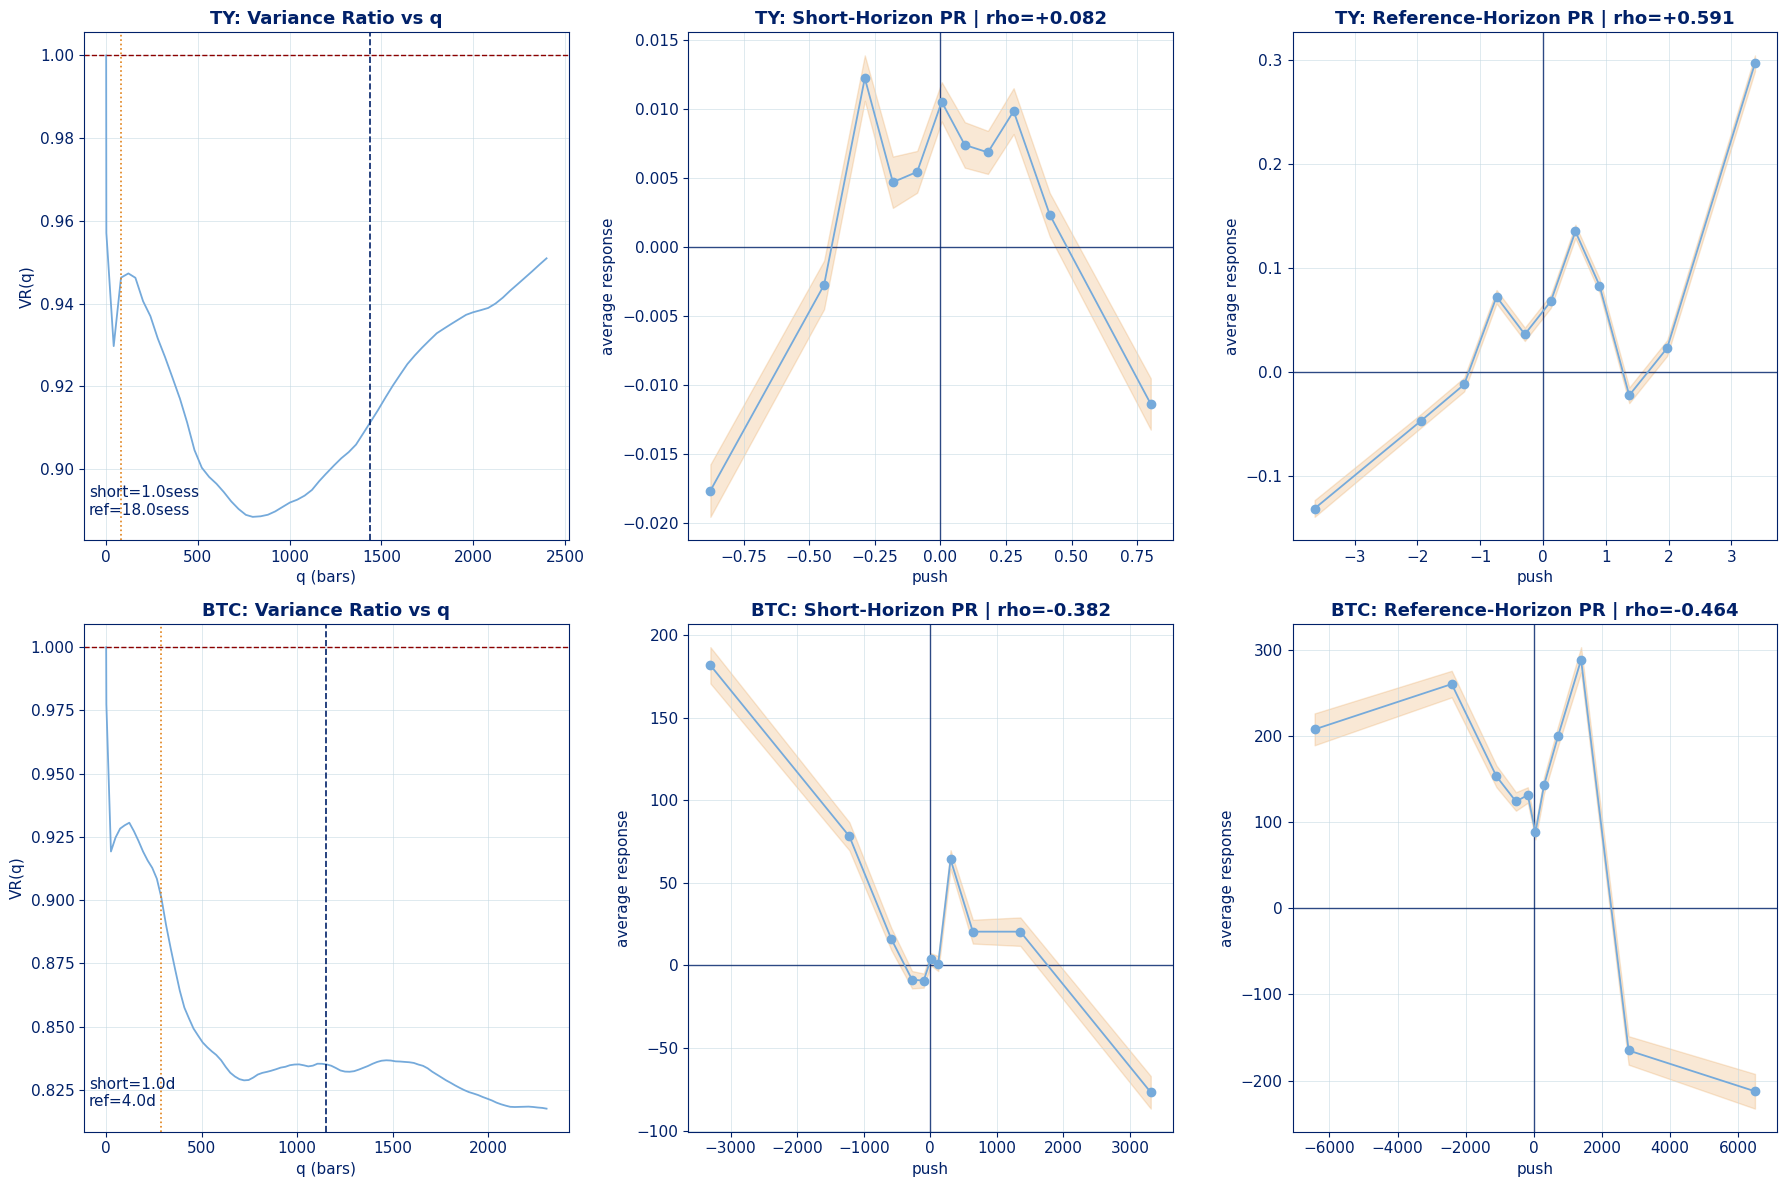

In [4]:
def _plot_pr(ax, pr_diag, title):
    if not pr_diag:
        ax.text(0.5, 0.5, 'No push-response data', ha='center', va='center')
        ax.set_title(title)
        return
    x = np.asarray(pr_diag['bin_centre'], dtype=float)
    y = np.asarray(pr_diag['bin_mean'], dtype=float)
    se = np.asarray(pr_diag['bin_se'], dtype=float)
    ax.axhline(0.0, color=COLUMBIA_NAVY, lw=1.0, alpha=0.8)
    ax.axvline(0.0, color=COLUMBIA_NAVY, lw=1.0, alpha=0.8)
    ax.plot(x, y, color=COLUMBIA_CORE, marker='o')
    ax.fill_between(x, y - se, y + se, color=COLUMBIA_WARM, alpha=0.18)
    ax.set_title(f"{title} | rho={pr_diag['spearman_rho']:+.3f}")
    ax.set_xlabel('push')
    ax.set_ylabel('average response')

fig, axes = plt.subplots(len(pair_story['tickers']), 3, figsize=(18, 6 * len(pair_story['tickers'])))
if len(pair_story['tickers']) == 1:
    axes = np.asarray([axes])

for row, ticker in enumerate(pair_story['tickers']):
    story = stories[ticker]
    professor_bundle = story['diagnostics']['professor_bundle']
    vr_curve_df = professor_bundle['vr_curve_df']
    ax0, ax1, ax2 = axes[row]
    ax0.plot(vr_curve_df['q'], vr_curve_df['VR'], color=COLUMBIA_CORE)
    ax0.axhline(1.0, color=COLUMBIA_RED, ls='--', lw=1.0)
    ax0.axvline(professor_bundle['short_tau'], color=COLUMBIA_WARM, ls=':', lw=1.2)
    ax0.axvline(professor_bundle['reference_tau'], color=COLUMBIA_NAVY, ls='--', lw=1.2)
    ax0.set_title(f"{ticker}: Variance Ratio vs q")
    ax0.set_xlabel('q (bars)')
    ax0.set_ylabel('VR(q)')
    ax0.text(0.01, 0.05, f"short={professor_bundle['short_scale']}\nref={professor_bundle['reference_scale']}", transform=ax0.transAxes, color=COLUMBIA_NAVY)
    _plot_pr(ax1, professor_bundle['short_pr'], f"{ticker}: Short-Horizon PR")
    _plot_pr(ax2, professor_bundle['reference_pr'], f"{ticker}: Reference-Horizon PR")

plt.tight_layout()
plt.show()

In [5]:
display(Markdown('## Presentation Cue'))
print('TY: show that the curve bends upward with horizon and emphasize that the trend-following property emerges around the month-scale reference horizon.')
print('BTC: show that the same diagnostics turn supportive earlier, which justifies a faster TF implementation.')

## Presentation Cue

TY: show that the curve bends upward with horizon and emphasize that the trend-following property emerges around the month-scale reference horizon.
BTC: show that the same diagnostics turn supportive earlier, which justifies a faster TF implementation.
